In [1]:
# ============================================
# VGG16 - FINAL STANDARDIZED SETUP
# ============================================

import os
import random
import time
import zipfile
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# ============================================
# REPRODUCIBILITY
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# DEVICE
# ============================================

if torch.cuda.is_available():

    device = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():

    device = torch.device("mps")

else:

    device = torch.device("cpu")


print("Device:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("Seed:", SEED)

Device: cuda
GPU: Tesla T4
Seed: 42


In [2]:
# ============================================
# DATASET LOCATION
# ============================================

possible_paths = [

    # Your Kaggle dataset
    "/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL",

    "/kaggle/input/aqua-plant-final-dataset/AquPlantDS_FINAL",

    # Colab structure used in old VGG notebook
    "/content/AquPlantDataset/AquPlantDS_FINAL",

    "/content/AquPlantDS_FINAL"
]


BASE_DIR = None

for path in possible_paths:

    if os.path.isdir(path):

        BASE_DIR = path
        break


# If Colab has ZIP but it has not been extracted
if BASE_DIR is None:

    zip_path = "/content/AquPlantDS_FINAL.zip"

    if os.path.exists(zip_path):

        extract_path = "/content/AquPlantDataset"

        os.makedirs(
            extract_path,
            exist_ok=True
        )

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as zip_ref:

            zip_ref.extractall(
                extract_path
            )

        candidate = os.path.join(
            extract_path,
            "AquPlantDS_FINAL"
        )

        if os.path.isdir(candidate):

            BASE_DIR = candidate


if BASE_DIR is None:

    raise FileNotFoundError(
        "AquPlantDS_FINAL dataset was not found."
    )


TRAIN_DIR = os.path.join(
    BASE_DIR,
    "Train"
)

VAL_DIR = os.path.join(
    BASE_DIR,
    "Validation"
)

TEST_DIR = os.path.join(
    BASE_DIR,
    "Test"
)


# Output location
if os.path.isdir("/kaggle/working"):

    OUTPUT_DIR = "/kaggle/working"

elif os.path.isdir("/content"):

    OUTPUT_DIR = "/content"

else:

    OUTPUT_DIR = "."


print("Dataset:", BASE_DIR)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test LOCKED:", TEST_DIR)
print("Output:", OUTPUT_DIR)

Dataset: /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL
Train: /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Train
Validation: /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Validation
Test LOCKED: /kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test
Output: /kaggle/working


In [3]:
# ============================================
# EXACT FROZEN PHASE-B PREPROCESSING
# ============================================

IMG_SIZE = 224
BATCH_SIZE = 32

mean = [
    0.485,
    0.456,
    0.406
]

std = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.RandomRotation(
        degrees=10,
        fill=(124, 116, 104)
    ),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean,
        std=std
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean,
        std=std
    )
])


print("Training transform ready ✅")
print("Validation transform ready ✅")

Training transform ready ✅
Validation transform ready ✅


In [4]:
# ============================================
# TRAIN + VALIDATION DATA ONLY
# TEST REMAINS LOCKED
# ============================================

train_data = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_data = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)


NUM_CLASSES = len(
    train_data.classes
)


# ============================================
# SAFETY CHECKS
# ============================================

assert NUM_CLASSES == 14, \
    f"Expected 14 classes, found {NUM_CLASSES}"

assert train_data.class_to_idx == \
       val_data.class_to_idx, \
       "Train/Validation class mapping mismatch."

assert len(train_data) == 744, \
    f"Expected 744 Train images, found {len(train_data)}"

assert len(val_data) == 161, \
    f"Expected 161 Validation images, found {len(val_data)}"


# ============================================
# REPRODUCIBLE DATALOADER
# ============================================

def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(SEED)


if device.type == "cuda":

    NUM_WORKERS = 2

else:

    NUM_WORKERS = 0


train_loader = DataLoader(

    train_data,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=(
        device.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=generator
)


val_loader = DataLoader(

    val_data,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        device.type == "cuda"
    )
)


print("====================================")
print("DATASET CHECK")
print("====================================")

print("Train images:", len(train_data))
print("Validation images:", len(val_data))
print("Classes:", NUM_CLASSES)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "\nTEST SET NOT LOADED ✅"
)

DATASET CHECK
Train images: 744
Validation images: 161
Classes: 14
Train batches: 24
Validation batches: 6

TEST SET NOT LOADED ✅


In [5]:
# ============================================
# VGG16 TRANSFER LEARNING
# STAGE 1 - FROZEN FEATURE EXTRACTOR
# ============================================

weights = (
    models.VGG16_Weights.IMAGENET1K_V1
)

vgg16 = models.vgg16(
    weights=weights
)


# ============================================
# FREEZE CONVOLUTIONAL BACKBONE
# ============================================

for param in vgg16.features.parameters():

    param.requires_grad = False


# ============================================
# REPLACE FINAL CLASSIFIER
# ============================================

in_features = (
    vgg16.classifier[6].in_features
)

vgg16.classifier[6] = nn.Linear(
    in_features,
    NUM_CLASSES
)


vgg16 = vgg16.to(device)


# ============================================
# PARAMETER INFORMATION
# ============================================

total_params = sum(
    p.numel()
    for p in vgg16.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vgg16.parameters()
    if p.requires_grad
)


print("VGG16 loaded ✅")

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Output classes:",
    NUM_CLASSES
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 237MB/s] 


VGG16 loaded ✅
Total parameters: 134,317,902
Trainable parameters: 119,603,214
Output classes: 14


In [6]:
# ============================================
# TRAINING CONFIGURATION
# ============================================

criterion = nn.CrossEntropyLoss()


optimizer = optim.AdamW(

    vgg16.classifier.parameters(),

    lr=0.0001,

    weight_decay=1e-4
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=3
    )
)


EPOCHS = 100
PATIENCE = 10


print("Loss: CrossEntropyLoss")
print("Optimizer: AdamW")
print("Scheduler: ReduceLROnPlateau")

print(
    "Maximum epochs:",
    EPOCHS
)

print(
    "Early stopping patience:",
    PATIENCE
)

print(
    "Best-model criterion:",
    "Validation Macro-F1"
)

Loss: CrossEntropyLoss
Optimizer: AdamW
Scheduler: ReduceLROnPlateau
Maximum epochs: 100
Early stopping patience: 10
Best-model criterion: Validation Macro-F1


In [7]:
# ============================================
# TRAINING FUNCTION
# ============================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        running_loss += (
            loss.item()
        )


        predictions = (
            outputs.argmax(dim=1)
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


    epoch_loss = (
        running_loss
        / len(loader)
    )


    epoch_accuracy = (
        correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )


# ============================================
# VALIDATION FUNCTION
# ============================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()


    running_loss = 0.0

    correct = 0
    total = 0


    all_predictions = []
    all_labels = []


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(images)


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (
                loss.item()
            )


            predictions = (
                outputs.argmax(dim=1)
            )


            correct += (
                predictions == labels
            ).sum().item()


            total += labels.size(0)


            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
            )

            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )


    val_loss = (
        running_loss
        / len(loader)
    )


    val_accuracy = (
        correct / total
    )


    val_precision = precision_score(

        all_labels,
        all_predictions,

        average="macro",

        zero_division=0
    )


    val_recall = recall_score(

        all_labels,
        all_predictions,

        average="macro",

        zero_division=0
    )


    val_f1 = f1_score(

        all_labels,
        all_predictions,

        average="macro",

        zero_division=0
    )


    val_weighted_f1 = f1_score(

        all_labels,
        all_predictions,

        average="weighted",

        zero_division=0
    )


    return (

        val_loss,

        val_accuracy,

        val_precision,

        val_recall,

        val_f1,

        val_weighted_f1
    )


print("Training function ready ✅")
print("Validation function ready ✅")

Training function ready ✅
Validation function ready ✅


In [8]:
# ============================================
# FINAL VGG16 STAGE-1 TRAINING
# Frozen convolutional backbone
# Best checkpoint = Validation Macro-F1
# ============================================

best_val_f1 = -1.0
best_epoch = 0

epochs_without_improvement = 0

history = []


stage1_model_path = os.path.join(
    OUTPUT_DIR,
    "vgg16_stage1_best_f1.pth"
)

stage1_history_path = os.path.join(
    OUTPUT_DIR,
    "vgg16_stage1_history.csv"
)


start_time = time.time()


for epoch in range(EPOCHS):

    # ========================================
    # TRAIN
    # ========================================

    (
        train_loss,
        train_accuracy
    ) = train_one_epoch(

        vgg16,

        train_loader,

        criterion,

        optimizer,

        device
    )


    # ========================================
    # VALIDATION
    # ========================================

    (
        val_loss,

        val_accuracy,

        val_precision,

        val_recall,

        val_f1,

        val_weighted_f1

    ) = validate_one_epoch(

        vgg16,

        val_loader,

        criterion,

        device
    )


    # ========================================
    # LR SCHEDULER
    # ========================================

    scheduler.step(
        val_loss
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    # ========================================
    # HISTORY
    # ========================================

    history.append({

        "epoch":
            epoch + 1,

        "train_loss":
            train_loss,

        "train_accuracy":
            train_accuracy,

        "val_loss":
            val_loss,

        "val_accuracy":
            val_accuracy,

        "val_precision_macro":
            val_precision,

        "val_recall_macro":
            val_recall,

        "val_f1_macro":
            val_f1,

        "val_f1_weighted":
            val_weighted_f1,

        "learning_rate":
            current_lr
    })


    pd.DataFrame(
        history
    ).to_csv(

        stage1_history_path,

        index=False
    )


    # ========================================
    # BEST MODEL BY MACRO-F1
    # ========================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_epoch = epoch + 1


        torch.save(

            vgg16.state_dict(),

            stage1_model_path
        )


        epochs_without_improvement = 0

        improvement_mark = " ⭐ BEST"


    else:

        epochs_without_improvement += 1

        improvement_mark = ""


    # ========================================
    # PRINT
    # ========================================

    print(

        f"Epoch {epoch + 1:03d}/{EPOCHS}"

        f" | Train Loss: "
        f"{train_loss:.4f}"

        f" | Train Acc: "
        f"{train_accuracy:.4f}"

        f" | Val Loss: "
        f"{val_loss:.4f}"

        f" | Val Acc: "
        f"{val_accuracy:.4f}"

        f" | Val F1: "
        f"{val_f1:.4f}"

        f" | LR: "
        f"{current_lr:.6f}"

        f"{improvement_mark}"
    )


    # ========================================
    # EARLY STOPPING
    # ========================================

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping triggered: "
            f"no Macro-F1 improvement "
            f"for {PATIENCE} epochs."
        )

        break


elapsed_time = (
    time.time()
    - start_time
)


# ============================================
# LOAD BEST STAGE-1 MODEL
# ============================================

vgg16.load_state_dict(

    torch.load(

        stage1_model_path,

        map_location=device,

        weights_only=True
    )
)


print(
    "\n===================================="
)

print(
    "VGG16 STAGE-1 TRAINING COMPLETE"
)

print(
    "===================================="
)


print(
    "Best Epoch:",
    best_epoch
)

print(

    "Best Validation Macro-F1:",

    round(
        best_val_f1 * 100,
        2
    ),

    "%"
)


print(

    "Training Time:",

    round(
        elapsed_time / 60,
        2
    ),

    "minutes"
)


print(
    "\nBest model saved:"
)

print(
    stage1_model_path
)


print(
    "\nHistory saved:"
)

print(
    stage1_history_path
)


print(
    "\nTEST SET WAS NOT USED ✅"
)

Epoch 001/100 | Train Loss: 1.9284 | Train Acc: 0.4140 | Val Loss: 0.9803 | Val Acc: 0.8137 | Val F1: 0.8137 | LR: 0.000100 ⭐ BEST
Epoch 002/100 | Train Loss: 0.6688 | Train Acc: 0.7944 | Val Loss: 0.4017 | Val Acc: 0.9006 | Val F1: 0.8999 | LR: 0.000100 ⭐ BEST
Epoch 003/100 | Train Loss: 0.3687 | Train Acc: 0.9005 | Val Loss: 0.2537 | Val Acc: 0.9317 | Val F1: 0.9321 | LR: 0.000100 ⭐ BEST
Epoch 004/100 | Train Loss: 0.1677 | Train Acc: 0.9664 | Val Loss: 0.2429 | Val Acc: 0.9068 | Val F1: 0.9073 | LR: 0.000100
Epoch 005/100 | Train Loss: 0.1332 | Train Acc: 0.9677 | Val Loss: 0.2247 | Val Acc: 0.9130 | Val F1: 0.9128 | LR: 0.000100
Epoch 006/100 | Train Loss: 0.0756 | Train Acc: 0.9825 | Val Loss: 0.1803 | Val Acc: 0.9317 | Val F1: 0.9322 | LR: 0.000100 ⭐ BEST
Epoch 007/100 | Train Loss: 0.0464 | Train Acc: 0.9946 | Val Loss: 0.1949 | Val Acc: 0.9255 | Val F1: 0.9252 | LR: 0.000100
Epoch 008/100 | Train Loss: 0.0447 | Train Acc: 0.9933 | Val Loss: 0.2133 | Val Acc: 0.9193 | Val F1: 0.

In [9]:
# ============================================
# VGG16 STAGE-1 SUMMARY
# ============================================

history_df = pd.read_csv(
    stage1_history_path
)


best_index = (
    history_df[
        "val_f1_macro"
    ].idxmax()
)


best_row = history_df.loc[
    best_index
]


print(
    "===================================="
)

print(
    "VGG16 FILE CHECK"
)

print(
    "===================================="
)


print(
    "History CSV exists:",
    os.path.exists(
        stage1_history_path
    )
)


print(
    "Best model exists:",
    os.path.exists(
        stage1_model_path
    )
)


print(
    "\n===================================="
)

print(
    "VGG16 BEST VALIDATION RESULT"
)

print(
    "===================================="
)


print(
    "Best Epoch:",
    int(
        best_row["epoch"]
    )
)


print(
    "Validation Accuracy:",
    round(
        best_row[
            "val_accuracy"
        ] * 100,
        2
    ),
    "%"
)


print(
    "Validation Precision:",
    round(
        best_row[
            "val_precision_macro"
        ] * 100,
        2
    ),
    "%"
)


print(
    "Validation Recall:",
    round(
        best_row[
            "val_recall_macro"
        ] * 100,
        2
    ),
    "%"
)


print(
    "Validation Macro-F1:",
    round(
        best_row[
            "val_f1_macro"
        ] * 100,
        2
    ),
    "%"
)


print(
    "Validation Weighted-F1:",
    round(
        best_row[
            "val_f1_weighted"
        ] * 100,
        2
    ),
    "%"
)


print(
    "Validation Loss:",
    round(
        best_row[
            "val_loss"
        ],
        4
    )
)


if os.path.exists(
    stage1_model_path
):

    model_size = (
        os.path.getsize(
            stage1_model_path
        )
        / (1024 * 1024)
    )


    print(
        "Saved Model Size:",
        round(
            model_size,
            2
        ),
        "MB"
    )


print(
    "\n===================================="
)

print(
    "VGG16 BASELINE COMPLETE ✅"
)

print(
    "Best model selected by Validation Macro-F1"
)

print(
    "Test set was NOT used ✅"
)

print(
    "===================================="
)

VGG16 FILE CHECK
History CSV exists: True
Best model exists: True

VGG16 BEST VALIDATION RESULT
Best Epoch: 24
Validation Accuracy: 97.52 %
Validation Precision: 97.61 %
Validation Recall: 97.6 %
Validation Macro-F1: 97.5 %
Validation Weighted-F1: 97.52 %
Validation Loss: 0.1508
Saved Model Size: 512.39 MB

VGG16 BASELINE COMPLETE ✅
Best model selected by Validation Macro-F1
Test set was NOT used ✅


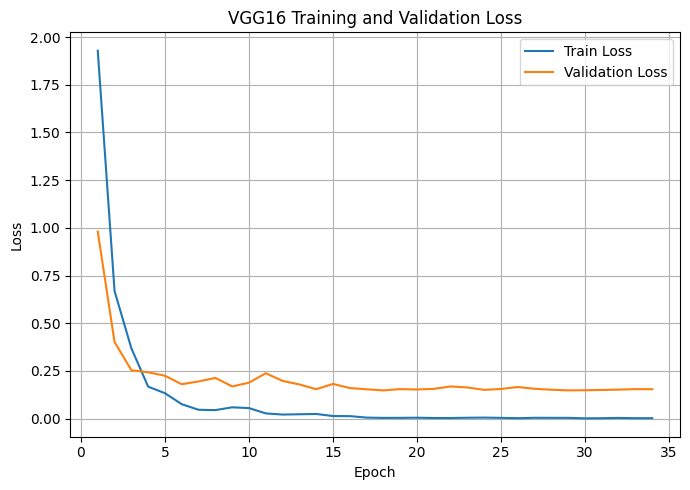

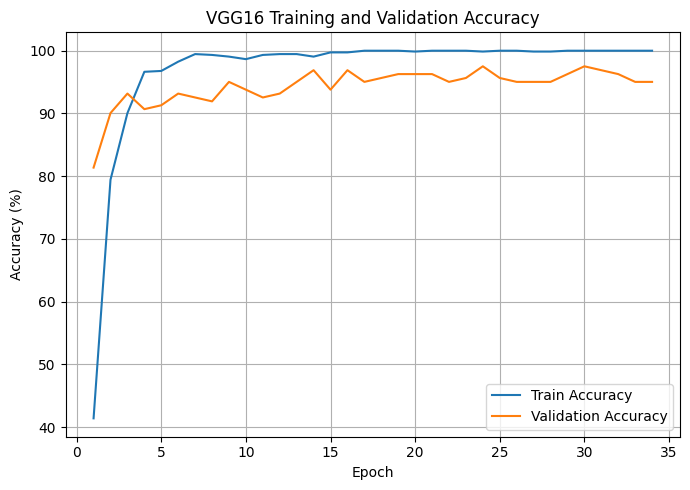

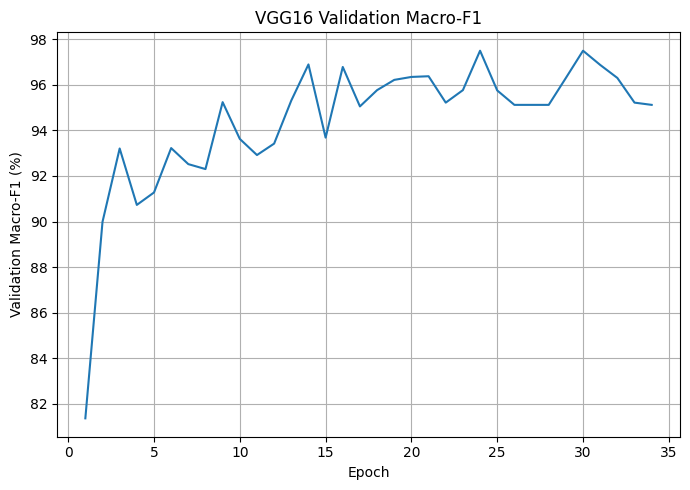

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

history_path = "/kaggle/working/vgg16_stage1_history.csv"

df = pd.read_csv(history_path)

# Loss curve
plt.figure(figsize=(7,5))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/vgg16_loss_curve.png", dpi=300)
plt.show()

# Accuracy curve
plt.figure(figsize=(7,5))
plt.plot(df["epoch"], df["train_accuracy"] * 100, label="Train Accuracy")
plt.plot(df["epoch"], df["val_accuracy"] * 100, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("VGG16 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/vgg16_accuracy_curve.png", dpi=300)
plt.show()

# Macro-F1 curve
plt.figure(figsize=(7,5))
plt.plot(df["epoch"], df["val_f1_macro"] * 100)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1 (%)")
plt.title("VGG16 Validation Macro-F1")
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/vgg16_f1_curve.png", dpi=300)
plt.show()

In [11]:
import zipfile
import os

files = [
    "/kaggle/working/vgg16_stage1_best_f1.pth",
    "/kaggle/working/vgg16_stage1_history.csv",
    "/kaggle/working/vgg16_loss_curve.png",
    "/kaggle/working/vgg16_accuracy_curve.png",
    "/kaggle/working/vgg16_f1_curve.png"
]

zip_path = "/kaggle/working/VGG16_Final_Artifacts.zip"

with zipfile.ZipFile(zip_path, "w") as z:
    for file in files:
        if os.path.exists(file):
            z.write(file, arcname=os.path.basename(file))

print("VGG16 artifacts ZIP created ✅")
print(zip_path)

VGG16 artifacts ZIP created ✅
/kaggle/working/VGG16_Final_Artifacts.zip


In [12]:
from IPython.display import FileLink, display

display(
    FileLink(
        "/kaggle/working/VGG16_Final_Artifacts.zip"
    )
)

/kaggle/working/VGG16_Final_Artifacts.zip

In [13]:
import os

source = "/kaggle/working/VGG16_Final_Artifacts.zip"
chunk_size = 100 * 1024 * 1024   # 100 MB

with open(source, "rb") as f:
    part = 1

    while True:
        data = f.read(chunk_size)

        if not data:
            break

        output = f"/kaggle/working/VGG16_part_{part:02d}.bin"

        with open(output, "wb") as out:
            out.write(data)

        print(
            f"Created: {os.path.basename(output)}",
            round(os.path.getsize(output)/(1024*1024), 2),
            "MB"
        )

        part += 1

print("Done ✅")

Created: VGG16_part_01.bin 100.0 MB
Created: VGG16_part_02.bin 100.0 MB
Created: VGG16_part_03.bin 100.0 MB
Created: VGG16_part_04.bin 100.0 MB
Created: VGG16_part_05.bin 100.0 MB
Created: VGG16_part_06.bin 12.78 MB
Done ✅
